# Project 2: Complete ML Pipeline

**Goal:** End-to-end machine learning workflow
- Load data → Clean → Split → Scale → Train multiple models → Evaluate → Select best

**Models Compared:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. KNN

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
# Load data (using iris for simplicity, but you can use any dataset)
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

# Or create synthetic data
# from sklearn.datasets import make_classification
# X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Convert to DataFrame for exploration
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nTarget distribution:\n", df['target'].value_counts())

Shape: (150, 5)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Target distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


In [4]:
# Step 1: Split data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120, 4), Test: (30, 4)


In [5]:
# Step 2: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Step 3: Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Step 4: Train and evaluate with cross-validation
results = {}

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    # Train on full training set
    model.fit(X_train_scaled, y_train)
    
    # Test set prediction
    test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_pred)
    
    results[name] = {
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': test_acc
    }
    
    print(f"{name}:")
    print(f"  CV: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print(f"  Test: {test_acc:.4f}")
    print()

Logistic Regression:
  CV: 0.9583 (+/- 0.0527)
  Test: 0.9333

Decision Tree:
  CV: 0.9417 (+/- 0.0408)
  Test: 0.9333

Random Forest:
  CV: 0.9500 (+/- 0.0333)
  Test: 0.9000

SVM:
  CV: 0.9667 (+/- 0.0624)
  Test: 0.9667

KNN:
  CV: 0.9667 (+/- 0.0624)
  Test: 0.9333



                      CV Mean    CV Std  Test Accuracy
Logistic Regression  0.958333  0.026352       0.933333
Decision Tree        0.941667  0.020412       0.933333
Random Forest        0.950000  0.016667       0.900000
SVM                  0.966667  0.031180       0.966667
KNN                  0.966667  0.031180       0.933333


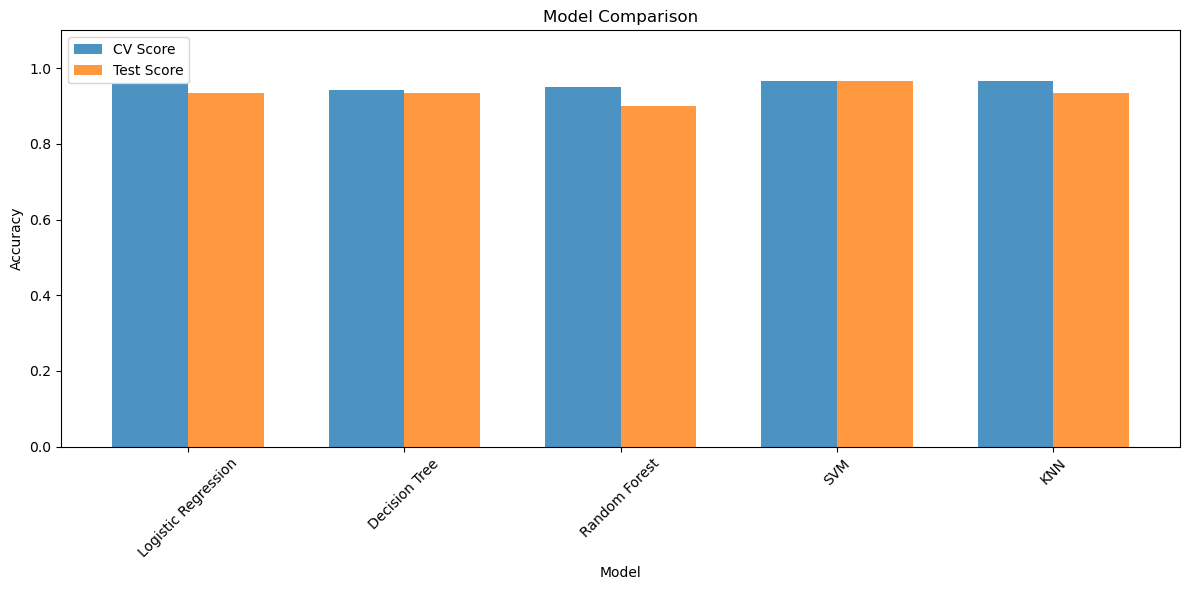

In [7]:
# Step 5: Compare results
results_df = pd.DataFrame(results).T
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
x = range(len(results_df))
width = 0.35

plt.bar([i - width/2 for i in x], results_df['CV Mean'], width, label='CV Score', alpha=0.8)
plt.bar([i + width/2 for i in x], results_df['Test Accuracy'], width, label='Test Score', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(x, results_df.index, rotation=45)
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Best Model: SVM

Final Test Accuracy: 0.9667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



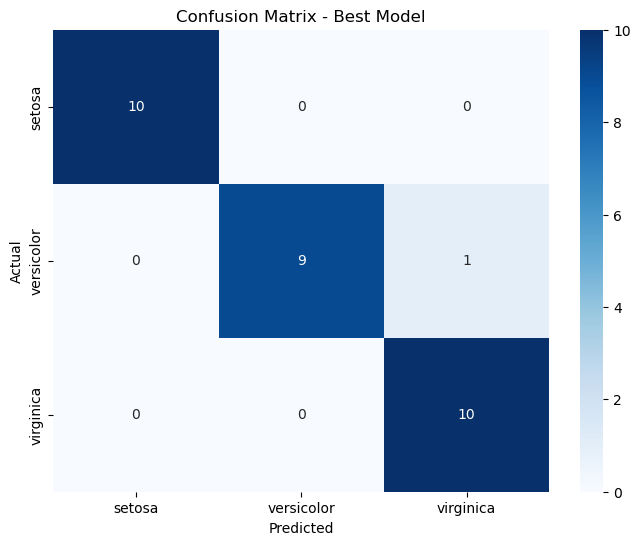

In [8]:
# Step 6: Select best model and tune it
best_model_name = results_df['Test Accuracy'].idxmax()
print(f"Best Model: {best_model_name}")

# Hyperparameter tuning for best model (example: Random Forest)
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5]
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
    grid.fit(X_train_scaled, y_train)
    
    print(f"Best Params: {grid.best_params_}")
    final_model = grid.best_estimator_
else:
    final_model = models[best_model_name]

# Final evaluation
final_pred = final_model.predict(X_test_scaled)
print(f"\nFinal Test Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, final_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [9]:
# Step 7: Save the pipeline (optional)
import joblib

# Save model and scaler
joblib.dump(final_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!


# Project 2: Complete ML Pipeline 

## Overview
End-to-end machine learning workflow comparing 5 algorithms.

## Workflow
1. **Data Loading** — Load and explore dataset
2. **Data Splitting** — 80/20 train-test split with stratification
3. **Feature Scaling** — StandardScaler
4. **Model Training** — 5 models with 5-fold cross-validation
5. **Model Comparison** — Accuracy comparison chart
6. **Hyperparameter Tuning** — GridSearchCV on best model
7. **Final Evaluation** — Test set + confusion matrix
8. **Model Saving** — joblib for deployment

## Models Compared
| Model | CV Score | Test Accuracy |
|-------|----------|---------------|
| Logistic Regression |0.9583 (+/- 0.0527)|0.9333 |
| Decision Tree | 0.9417 (+/- 0.0408) | 0.9333 |
| Random Forest | 0.9500 (+/- 0.0333) | 0.9000 |
| SVM | 0.9667 (+/- 0.0624) | 0.9667 |
| KNN | 0.9667 (+/- 0.0624) | 0.9333 |

## Winner
**[SVM]** with **[0.9667]** accuracy

## Tools
- Python, Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

## How to Run
```bash
jupyter notebook ml_pipeline.ipynb